# MVP Soccer Match Prediction Model

This notebook demonstrates loading the `game_features.parquet` dataset, performing exploratory data analysis, and training an MVP Neural Network (MLPClassifier) for predicting match outcomes (W/D/L).


## 1. Imports and Setup


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


## 2. Load Data


In [4]:
# Determine the path to the data file
# Try relative path first
data_path = Path("../../Data/game_features.parquet")

# Alternative paths if running from different locations
if not data_path.exists():
    data_path = Path("PROJECT 3/Code/Data/game_features.parquet")
if not data_path.exists():
    data_path = Path("../Data/game_features.parquet")
if not data_path.exists():
    # Absolute path as last resort
    import os
    data_path = Path(os.getcwd()) / "PROJECT 3" / "Code" / "Data" / "game_features.parquet"

print(f"Loading data from: {data_path}")

# Load the Parquet file
df = pd.read_parquet(data_path)

print(f"\nDataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
print(f"\nFirst few rows:")
df.head()


Loading data from: ..\Data\game_features.parquet

Dataset loaded successfully!
Shape: 74,035 rows × 172 columns

First few rows:


,ID_GAME,ID_COMPETITION,ID_SEASON,ID_ROUND,ID_DATE,ID_HOME_CLUB,ID_AWAY_CLUB,ID_HOME_TEAM,ID_AWAY_TEAM,ID_HOME_MANAGER,...,diff_goals_scored_L10,diff_points_L20,diff_goal_difference_L20,diff_goals_scored_L20,diff_squad_value_total_L5,diff_avg_age_L5,diff_avg_height_L5,diff_squad_value_total_L20,diff_avg_age_L20,diff_avg_height_L20
0,2231978,CLQ,2012,First Round 1st leg,2012-07-03,853.0,10747.0,None,None,Didier Philippe,...,0.777778,19.0,0.631579,0.947368,NaN,NaN,NaN,1.471803e+08,-5.041706,5.356134
1,2231979,CLQ,2012,First Round 1st leg,2012-07-03,3471.0,10532.0,None,None,David Jeffrey,...,-0.500000,-15.0,-1.588235,-1.000000,5.833333e+04,8.125029,NaN,7.569444e+04,8.879893,NaN
2,2231982,CLQ,2012,First Round 1st leg,2012-07-03,6335.0,28958.0,None,None,Mark Miller,...,2.583333,21.0,2.845201,2.309598,-1.438333e+06,2.920773,-2.225694,-2.105285e+06,-0.517824,-2.375209
3,2234412,ELQ,2012,First Round 1st leg,2012-07-03,24832.0,10694.0,None,None,Jógvan Martin Olsen,...,0.425000,-6.0,-0.563492,0.515873,NaN,NaN,NaN,NaN,NaN,NaN
4,2235764,ELQ,2012,First Round 1st leg,2012-07-03,1167.0,5594.0,None,None,Qatip Osmani,...,-1.111111,-14.0,-1.210526,-1.368421,1.829875e+08,-0.876317,6.452608,1.749504e+08,1.772689,1.422303


## 3. Exploratory Data Analysis (EDA)


### 3.1 Target Variable Distribution


Target variable distribution:
RESULT
W    33481
L    24696
D    15858
Name: count, dtype: Int64

Percentages:
RESULT
W    45.223205
L    33.357196
D    21.419599
Name: count, dtype: Float64


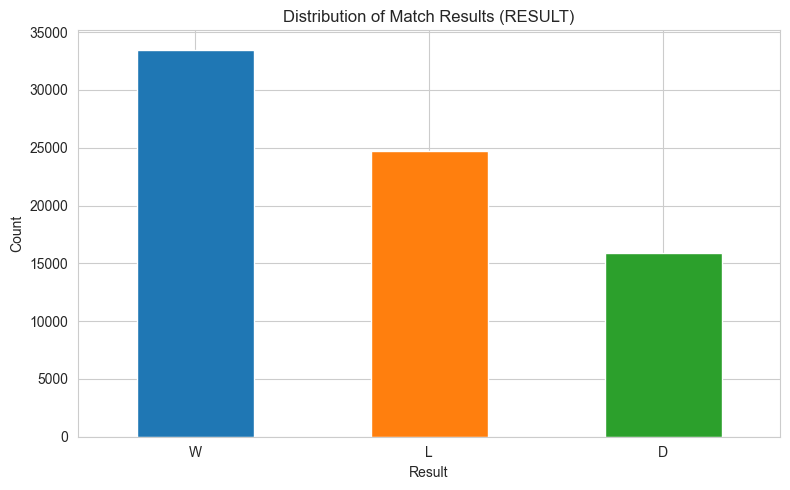

In [5]:
# Check target variable distribution
if 'RESULT' in df.columns:
    target_dist = df['RESULT'].value_counts()
    print("Target variable distribution:")
    print(target_dist)
    print(f"\nPercentages:")
    print(target_dist / len(df) * 100)
    
    # Visualize
    plt.figure(figsize=(8, 5))
    target_dist.plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    plt.title('Distribution of Match Results (RESULT)')
    plt.xlabel('Result')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("RESULT column not found in dataset")


### 3.2 Data Types and Missing Values


In [6]:
# Check data types
print("Data types:")
print(df.dtypes.value_counts())
print(f"\nTotal columns: {len(df.columns)}")

# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print("\nColumns with missing values:")
print(missing_df[missing_df['Missing Count'] > 0].head(20))


Data types:
float64           155
object             13
int64               2
datetime64[ns]      1
string[python]      1
Name: count, dtype: int64

Total columns: 172

Columns with missing values:
                                           Missing Count  Missing %
home_club_position                                 22476  30.358614
away_club_position                                 22476  30.358614
diff_avg_height_L5                                 16542  22.343486
diff_avg_age_L5                                    16361  22.099007
home_max_height_mean_L5                            14527  19.621800
home_avg_height_mean_L5                            14527  19.621800
home_min_height_mean_L5                            14527  19.621800
diff_squad_value_total_L5                          14481  19.559668
home_avg_age_mean_L5                               14380  19.423246
home_median_age_mean_L5                            14380  19.423246
away_min_height_mean_L5                            142

### 3.3 Descriptive Statistics


In [7]:
# Get numeric predictor columns (exclude metadata and target)
metadata_cols = [col for col in df.columns if col.startswith('ID_')]
target_col = 'RESULT' if 'RESULT' in df.columns else None

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
predictor_cols = [col for col in numeric_cols if col not in metadata_cols and col != target_col]

print(f"Metadata columns: {len(metadata_cols)}")
print(f"Target column: {target_col}")
print(f"Numeric predictor features: {len(predictor_cols)}")

# Display descriptive statistics for a sample of predictors
if predictor_cols:
    sample_cols = predictor_cols[:10]  # First 10 predictors
    print(f"\nDescriptive statistics (sample of {len(sample_cols)} predictors):")
    print(df[sample_cols].describe())


Metadata columns: 22
Target column: RESULT
Numeric predictor features: 149

Descriptive statistics (sample of 10 predictors):
       home_club_position  away_club_position  home_points_sum_L3  \
count        51559.000000        51559.000000        73904.000000   
mean             9.273667            9.453345            4.085205   
std              5.297962            5.317900            2.465097   
min              1.000000            1.000000            0.000000   
25%              5.000000            5.000000            3.000000   
50%              9.000000            9.000000            4.000000   
75%             14.000000           14.000000            6.000000   
max             21.000000           21.000000            9.000000   

       home_goal_difference_mean_L3  home_goals_scored_mean_L3  \
count                  73904.000000               73904.000000   
mean                      -0.008213                   1.465148   
std                        1.259063                   

## 4. Data Preprocessing


### 4.1 Prepare Features and Target


In [8]:
# Separate metadata, target, and predictors
metadata_cols = [col for col in df.columns if col.startswith('ID_')]
target_col = 'RESULT' if 'RESULT' in df.columns else None

# Get all numeric predictor columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
predictor_cols = [col for col in numeric_cols if col not in metadata_cols and col != target_col]

# Extract features and target
X = df[predictor_cols].copy()
y = df[target_col].copy() if target_col else None

print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape if y is not None else 'N/A'}")

# Filter out predictors with >50% missing values
missing_threshold = 0.5
missing_pct = X.isnull().sum() / len(X)
valid_cols = missing_pct[missing_pct <= missing_threshold].index.tolist()

print(f"\nPredictors with >{missing_threshold*100}% missing: {len(predictor_cols) - len(valid_cols)}")
X = X[valid_cols]
predictor_cols = valid_cols

print(f"Valid predictors after filtering: {len(predictor_cols)}")


Features (X): (74035, 149)
Target (y): (74035,)

Predictors with >50.0% missing: 0
Valid predictors after filtering: 149


### 4.2 Handle Missing Values and Encode Target


In [9]:
# Fill remaining missing values with median
X_filled = X.fillna(X.median())

print(f"Missing values after filling: {X_filled.isnull().sum().sum()}")

# Encode target variable
if y is not None:
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    
    print(f"\nTarget encoding:")
    print(f"  Classes: {le.classes_}")
    print(f"  Encoded: {np.unique(y_encoded, return_counts=True)}")
else:
    y_encoded = None
    print("No target variable found")


Missing values after filling: 0

Target encoding:
  Classes: ['D' 'L' 'W']
  Encoded: (array([0, 1, 2]), array([15858, 24696, 33481]))


### 4.3 Train-Test Split (Temporal Split)


In [10]:
# Split into train and test sets (using temporal split if ID_DATE exists)
if 'ID_DATE' in df.columns and target_col:
    # Temporal split: use earlier games for training, later for testing
    dates = pd.to_datetime(df.loc[X.index, 'ID_DATE'])
    split_date = dates.quantile(0.8)  # 80% for training
    
    train_mask = dates < split_date
    test_mask = dates >= split_date
    
    X_train = X_filled[train_mask]
    X_test = X_filled[test_mask]
    y_train = y_encoded[train_mask]
    y_test = y_encoded[test_mask]
    
    print(f"Temporal split:")
    print(f"  Split date: {split_date.date()}")
    print(f"  Training set: {len(X_train):,} games ({len(X_train)/len(X_filled)*100:.1f}%)")
    print(f"  Test set: {len(X_test):,} games ({len(X_test)/len(X_filled)*100:.1f}%)")
else:
    # Random split
    X_train, X_test, y_train, y_test = train_test_split(
        X_filled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )
    print(f"Random split:")
    print(f"  Training set: {len(X_train):,} games ({len(X_train)/len(X_filled)*100:.1f}%)")
    print(f"  Test set: {len(X_test):,} games ({len(X_test)/len(X_filled)*100:.1f}%)")


Temporal split:
  Split date: 2022-10-22
  Training set: 59,184 games (79.9%)
  Test set: 14,851 games (20.1%)


### 4.4 Scale Features


In [11]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Features scaled:")
print(f"  Training shape: {X_train_scaled.shape}")
print(f"  Test shape: {X_test_scaled.shape}")


Features scaled:
  Training shape: (59184, 149)
  Test shape: (14851, 149)


## 5. MVP Neural Network Model (MLPClassifier)


For this MVP, we'll use a Multi-Layer Perceptron (MLPClassifier) from scikit-learn as a simplified version of a neural network. This is a good starting point before implementing a more complex RNN/LSTM model.


In [12]:
# Train MLPClassifier
print("Training MLPClassifier...")

mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),  # Two hidden layers: 100 and 50 neurons
    activation='relu',
    solver='adam',
    alpha=0.0001,  # L2 regularization
    batch_size='auto',
    learning_rate='constant',
    learning_rate_init=0.001,
    max_iter=500,
    shuffle=True,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    verbose=True
)

mlp.fit(X_train_scaled, y_train)
print("\nTraining complete!")


Training MLPClassifier...
Iteration 1, loss = 0.95640736
Validation score: 0.567495
Iteration 2, loss = 0.90108950
Validation score: 0.571211
Iteration 3, loss = 0.88599487
Validation score: 0.574083
Iteration 4, loss = 0.87634406
Validation score: 0.566312
Iteration 5, loss = 0.86893009
Validation score: 0.572901
Iteration 6, loss = 0.86092488
Validation score: 0.566312
Iteration 7, loss = 0.85466454
Validation score: 0.572563
Iteration 8, loss = 0.84685242
Validation score: 0.571549
Iteration 9, loss = 0.84003719
Validation score: 0.557865
Iteration 10, loss = 0.83360905
Validation score: 0.565298
Iteration 11, loss = 0.82650931
Validation score: 0.560399
Iteration 12, loss = 0.81797203
Validation score: 0.559216
Iteration 13, loss = 0.81289455
Validation score: 0.566650
Iteration 14, loss = 0.80645947
Validation score: 0.559723
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.

Training complete!


In [13]:
# Make predictions
y_train_pred = mlp.predict(X_train_scaled)
y_test_pred = mlp.predict(X_test_scaled)

# Calculate accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Model Performance:")
print(f"  Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"  Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")


Model Performance:
  Training Accuracy: 0.5976 (59.76%)
  Test Accuracy: 0.5783 (57.83%)


### 5.2 Classification Report


In [14]:
# Detailed classification report
if y is not None and hasattr(le, 'classes_'):
    class_names = le.classes_
    print("\nClassification Report (Test Set):")
    print(classification_report(y_test, y_test_pred, target_names=class_names))
else:
    print("\nClassification Report (Test Set):")
    print(classification_report(y_test, y_test_pred))



Classification Report (Test Set):
              precision    recall  f1-score   support

           D       0.32      0.05      0.09      3051
           L       0.56      0.63      0.59      5109
           W       0.60      0.78      0.68      6691

    accuracy                           0.58     14851
   macro avg       0.50      0.49      0.45     14851
weighted avg       0.53      0.58      0.53     14851



### 5.3 Confusion Matrix


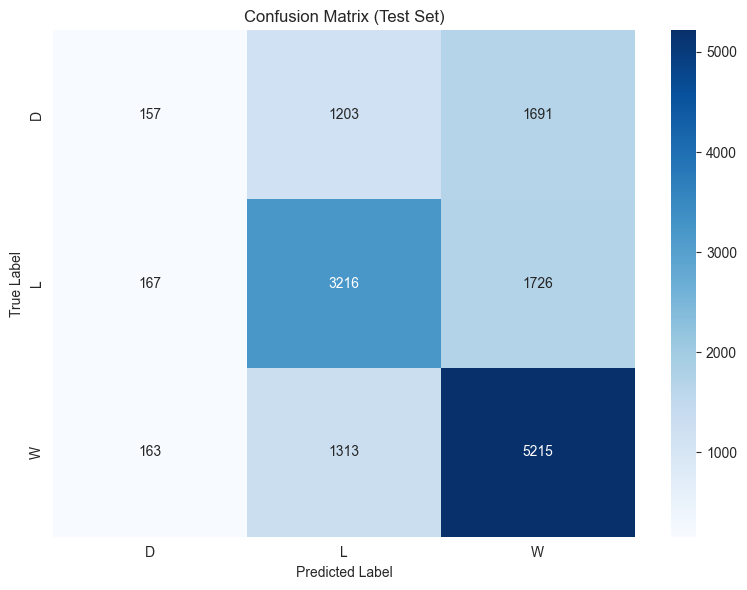


Confusion Matrix:
[[ 157 1203 1691]
 [ 167 3216 1726]
 [ 163 1313 5215]]


In [15]:
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

if y is not None and hasattr(le, 'classes_'):
    class_names = le.classes_
else:
    class_names = [f"Class {i}" for i in range(len(np.unique(y_test)))]

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix:")
print(cm)


### 5.4 Model Summary


In [16]:
print("Model Architecture Summary:")
print(f"  Input features: {X_train_scaled.shape[1]}")
print(f"  Hidden layers: {mlp.hidden_layer_sizes}")
print(f"  Output classes: {mlp.n_outputs_}")
print(f"  Total iterations: {mlp.n_iter_}")
print(f"  Loss: {mlp.loss_:.4f}")


Model Architecture Summary:
  Input features: 149
  Hidden layers: (100, 50)
  Output classes: 3
  Total iterations: 14
  Loss: 0.8065


## 6. Summary and Next Steps

### Summary
- Successfully loaded the `game_features.parquet` dataset
- Performed exploratory data analysis
- Preprocessed the data (handled missing values, encoded target, scaled features)
- Trained an MVP MLPClassifier model
- Evaluated the model performance

### Next Steps for Improvement
1. **Feature Engineering**: Explore feature importance, remove redundant features
2. **Hyperparameter Tuning**: Use GridSearchCV or RandomizedSearchCV
3. **True RNN/LSTM**: Implement sequence models to capture temporal dependencies
4. **Ensemble Methods**: Combine multiple models for better performance
5. **Cross-Validation**: Use time-series cross-validation for more robust evaluation
6. **Feature Selection**: Use techniques like mutual information or permutation importance
